In [1]:
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt

from sklearn.metrics import classification_report

from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications import EfficientNetB3
from tensorflow.keras.applications.efficientnet import preprocess_input

from tensorflow.keras.layers import (
    Dense,
    Dropout,
    GlobalAveragePooling2D,
    BatchNormalization
)

from tensorflow.keras.models import Model

from tensorflow.keras.callbacks import (
    EarlyStopping,
    ReduceLROnPlateau,
    ModelCheckpoint
)

# SETTINGS

IMG_SIZE = 300
BATCH_SIZE = 16
EPOCHS_STAGE1 = 10
EPOCHS_STAGE2 = 10

TRAIN_DIR = "dataset/Training"
TEST_DIR = "dataset/Testing"

# DATA GENERATORS

train_datagen = ImageDataGenerator(
    preprocessing_function=preprocess_input,
    validation_split=0.2,
    rotation_range=10,
    zoom_range=0.1,
    width_shift_range=0.1,
    height_shift_range=0.1
)

test_datagen = ImageDataGenerator(
    preprocessing_function=preprocess_input
)

train_generator = train_datagen.flow_from_directory(
    TRAIN_DIR,
    target_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE,
    class_mode="categorical",
    subset="training"
)

val_generator = train_datagen.flow_from_directory(
    TRAIN_DIR,
    target_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE,
    class_mode="categorical",
    subset="validation"
)

test_generator = test_datagen.flow_from_directory(
    TEST_DIR,
    target_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE,
    class_mode="categorical",
    shuffle=False
)

print("Class Mapping:")
print(train_generator.class_indices)

# MODEL

base_model = EfficientNetB3(
    weights="imagenet",
    include_top=False,
    input_shape=(IMG_SIZE, IMG_SIZE, 3)
)

base_model.trainable = False

x = base_model.output

x = GlobalAveragePooling2D()(x)

x = Dense(512, activation="relu")(x)
x = BatchNormalization()(x)
x = Dropout(0.3)(x)

x = Dense(256, activation="relu")(x)
x = BatchNormalization()(x)
x = Dropout(0.2)(x)

output = Dense(4, activation="softmax")(x)

model = Model(
    inputs=base_model.input,
    outputs=output
)

# COMPILE STAGE 1

model.compile(
    optimizer=tf.keras.optimizers.Adam(1e-3),
    loss="categorical_crossentropy",
    metrics=["accuracy"]
)

# CALLBACKS

early_stop = EarlyStopping(
    monitor="val_loss",
    patience=5,
    restore_best_weights=True
)

reduce_lr = ReduceLROnPlateau(
    monitor="val_loss",
    factor=0.2,
    patience=2,
    verbose=1
)

checkpoint = ModelCheckpoint(
    "best_brain_tumor_model.keras",
    monitor="val_accuracy",
    save_best_only=True,
    mode="max",
    verbose=1
)

# STAGE 1 TRAINING

history1 = model.fit(
    train_generator,
    validation_data=val_generator,
    epochs=EPOCHS_STAGE1,
    callbacks=[
        early_stop,
        reduce_lr,
        checkpoint
    ]
)

# FINE TUNING

base_model.trainable = True

for layer in base_model.layers[:-50]:
    layer.trainable = False

model.compile(
    optimizer=tf.keras.optimizers.Adam(1e-5),
    loss="categorical_crossentropy",
    metrics=["accuracy"]
)

# STAGE 2 TRAINING

history2 = model.fit(
    train_generator,
    validation_data=val_generator,
    epochs=EPOCHS_STAGE2,
    callbacks=[
        early_stop,
        reduce_lr,
        checkpoint
    ]
)

Found 4480 images belonging to 4 classes.
Found 1120 images belonging to 4 classes.
Found 1600 images belonging to 4 classes.
Class Mapping:
{'glioma': 0, 'meningioma': 1, 'notumor': 2, 'pituitary': 3}
Epoch 1/10
280/280 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.7365 - loss: 0.7732
Epoch 1: val_accuracy improved from None to 0.88661, saving model to best_brain_tumor_model.keras

Epoch 1: finished saving model to best_brain_tumor_model.keras
280/280 ━━━━━━━━━━━━━━━━━━━━ 470s 2s/step - accuracy: 0.7953 - loss: 0.5939 - val_accuracy: 0.8866 - val_loss: 0.3014 - learning_rate: 0.0010
Epoch 2/10
280/280 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.8523 - loss: 0.3903
Epoch 2: val_accuracy improved from 0.88661 to 0.89643, saving model to best_brain_tumor_model.keras

Epoch 2: finished saving model to best_brain_tumor_model.keras
280/280 ━━━━━━━━━━━━━━━━━━━━ 470s 2s/step - accuracy: 0.8531 - loss: 0.3997 - val_accuracy: 0.8964 - val_loss: 0.2870 - learning_rate: 0.0010
Epoch 3/10
280/28

100/100 ━━━━━━━━━━━━━━━━━━━━ 234s 2s/step - accuracy: 0.8462 - loss: 0.4960

Test Accuracy: 84.62%
100/100 ━━━━━━━━━━━━━━━━━━━━ 240s 2s/step
              precision    recall  f1-score   support

      glioma       0.90      0.69      0.78       400
  meningioma       0.78      0.75      0.76       400
     notumor       0.83      0.98      0.90       400
   pituitary       0.89      0.96      0.93       400

    accuracy                           0.85      1600
   macro avg       0.85      0.85      0.84      1600
weighted avg       0.85      0.85      0.84      1600



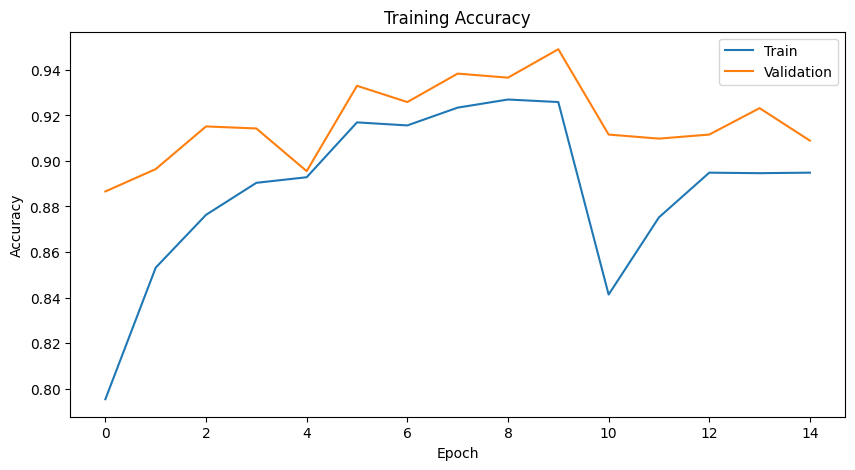

In [2]:
# SAVE MODEL

model.save("brain_tumor_final.keras")

# EVALUATION

loss, accuracy = model.evaluate(test_generator)

print(f"\nTest Accuracy: {accuracy*100:.2f}%")

# CLASSIFICATION REPORT

predictions = model.predict(test_generator)

predicted_classes = np.argmax(
    predictions,
    axis=1
)

true_classes = test_generator.classes

class_names = list(
    test_generator.class_indices.keys()
)

print(
    classification_report(
        true_classes,
        predicted_classes,
        target_names=class_names
    )
)

# ACCURACY GRAPH

plt.figure(figsize=(10,5))

plt.plot(
    history1.history["accuracy"] +
    history2.history["accuracy"]
)

plt.plot(
    history1.history["val_accuracy"] +
    history2.history["val_accuracy"]
)

plt.title("Training Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend(["Train", "Validation"])

plt.show()